# Using DecisionTreeClassifier to Classify Forest Fires in Algeria

In this notebook, we apply a decision tree classifier to explore if we can predict whether or not a forst fire occurred. This [Algerian Forest Fires dataset](https://archive.ics.uci.edu/dataset/547/algerian+forest+fires+dataset) comes from UC Irvine's Machine Learning Repository.

This dataset records daily weather and fire-weather index (FWI) system readings from two Algerian regions: the northeast region of Bejaia and the northwest region of Sidi Bel-abbes (northwest). Data was collected from June–September 2012.

The task is **binary classification**: given weather conditions on a given day, predict whether a fire occurred or not.

**Features:**
| **Feature** | **Type** | **Description** |
|---|---|---|
| Temperature | Integer | Noon temperature (°C) |
| RH | Integer | Relative Humidity (%) |
| Ws | Integer | Wind speed (km/h) |
| Rain | Continuous | Total daily rain (mm) |
| FFMC | Continuous | Fine Fuel Moisture Code index |
| DMC | Continuous | Duff Moisture Code index |
| DC | Continuous | Drought Code index |
| ISI | Continuous | Initial Spread Index |
| BUI | Continuous | Buildup Index |
| FWI | Continuous | Fire Weather Index |
| Classes | Categorical | Fire (1) / Not Fire (0) |

**Target:** `Classes` — `fire` or `not fire`

---

## Load and Explore Data

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_package import (
    DecisionTreeClassifier,
    StandardScaler,
    train_test_split,
    randomized_search_cv,
    classification_metrics,
)

np.random.seed(42)

In [ ]:
# Load data and assign features and target
df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv")
X = df.drop(columns = ["day", "month", "year", "Classes"])
y = df["Classes"]

# Clean class labels (strip whitespace)
y = np.array([str(v).strip() for v in y])

print(f"Class balance: { {c: (y == c).sum() for c in np.unique(y)} }")

df.head()

Class balance: {np.str_('Classes'): np.int64(1), np.str_('fire'): np.int64(137), np.str_('nan'): np.int64(3), np.str_('not fire'): np.int64(106)}


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [17]:
# Coerce all columns to numeric (some may have stray spaces)
X_clean = X.apply(pd.to_numeric, errors="coerce")
X_clean.dropna(inplace=True)
y_clean = y[:len(X_clean)]
print(f"After cleaning: {X_clean.shape}")
print(X_clean.describe().round(2).to_string())


After cleaning: (243, 10)
       Temperature      RH      Ws    Rain    FFMC     DMC      DC     ISI     BUI     FWI
count       243.00  243.00  243.00  243.00  243.00  243.00  243.00  243.00  243.00  243.00
mean         32.15   62.04   15.49    0.76   77.84   14.68   49.43    4.74   16.69    7.04
std           3.63   14.83    2.81    2.00   14.35   12.39   47.67    4.15   14.23    7.44
min          22.00   21.00    6.00    0.00   28.60    0.70    6.90    0.00    1.10    0.00
25%          30.00   52.50   14.00    0.00   71.85    5.80   12.35    1.40    6.00    0.70
50%          32.00   63.00   15.00    0.00   83.30   11.30   33.10    3.50   12.40    4.20
75%          35.00   73.50   17.00    0.50   88.30   20.80   69.10    7.25   22.65   11.45
max          42.00   90.00   29.00   16.80   96.00   65.90  220.40   19.00   68.00   31.10


## Data Preprocessing

We encode the label as binary: fire = 1, not fire = 0. Unlike linear models, decision trees don't require feature scaling as the splits are threshold-based comparisons. We still use a stratified split to preserve the 59/41 class ratio.

---

In [19]:
y = (y_clean == "fire").astype(int)
X_arr = X_clean.values.astype(float)
feat_names = list(X_clean.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Fire rate in test:  {y_test.mean():.3f}")


Train: 194  |  Test: 49
Fire rate in test:  0.571


## Randomized Search over `max_depth` and `criterion`

We run 5-fold cross-validation for three depths (2, 5, 8) and two split criteria (entropy and Gini impurity). This 3×2 grid produces 6 cross-validated accuracy estimates.

---

In [21]:
#Define grid of hyperparameters to tune over with our DecisionTreeClassifier class
param_distributions = {
    "max_depth": [2, 5, 8],
    "criterion": ["entropy", "gini"]
}

In [23]:
# Run the randomized search
search_results = randomized_search_cv(
    estimator = DecisionTreeClassifier,
    param_distributions = param_distributions,
    X = X_train,
    y = y_train,
    n_iter = 10,
    n_splits = 5,
    scoring = "score",    
    fit_method = "fit",
    random_state = 42,
    refit = True,          
)

print(f"Best CV accuracy  : {search_results['best_score']:.4f}")
print(f"Best params : {search_results['best_params']}")

Best CV accuracy  : 0.7578
Best params : {'max_depth': 2, 'criterion': 'entropy'}


---

The randomized search found that the best parameters are `max_depth` = 2 and `criterion` = "entropy". Now that we have our hyperparameters, we can fit the model.

---

## Final Model

In [27]:
model = DecisionTreeClassifier(max_depth = 2, criterion = "entropy")
model.fit(X_train, y_train)

print(f"  Accuracy  : {model.accuracy(X_test, y_test):.4f}")
print(f"  Precision : {model.precision(X_test, y_test, average='binary'):.4f}")
print(f"  Recall    : {model.recall(X_test, y_test, average='binary'):.4f}")
print(f"  F1 Score  : {model.f1_score(X_test, y_test, average='binary'):.4f}")

  Accuracy  : 0.7755
  Precision : 0.7742
  Recall    : 0.8571
  F1 Score  : 0.8136


---

The decision tree classifier returned classification accuracy metrics around the 77% to 86% range, which shows that it performed well on the test set! However, given the dataset's small size, we note that test set performance may have moderate variance; a bootstrap confidence interval would be a useful extension of this example.

---

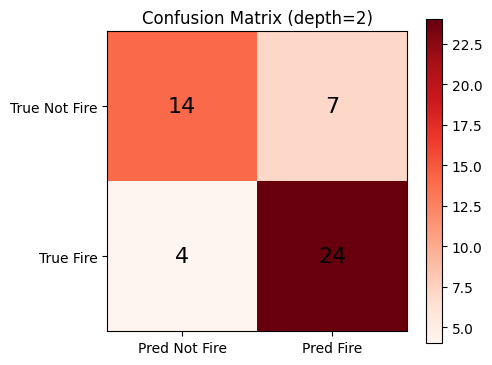

In [29]:
cm = model.confusion_matrix(X_test, y_test)
labels_display = ["Not Fire", "Fire"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Reds")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels([f"Pred {l}" for l in labels_display], fontsize=10)
ax.set_yticklabels([f"True {l}" for l in labels_display], fontsize=10)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16)
plt.colorbar(im, ax=ax)
ax.set_title(f"Confusion Matrix (depth={2})")
plt.tight_layout()
plt.show()


## Print Fitted Tree

The method `model.print_tree()` outputs the fitted tree as an indented text structure. Each node shows the split feature and threshold, and each leaf shows the predicted class. This interpretability gives decision trees a strong practical advantage. In the context of this dataset, for example, a park ranger could monitor conditions present in each region and follow the decision tree's logic to make informed decisions on how to prepare for potential fires.

---

In [30]:
print(f"Decision Tree Structure (max_depth={2}):")
model.print_tree(model.tree_, spacing="  ", feature_names=feat_names)

Decision Tree Structure (max_depth=2):
  [ISI <= 1.9000]
    ---> True
       [ RH <= 64.0000]
         ---> True
            Predict: 0  {np.int64(0): np.int64(10), np.int64(1): np.int64(7)}
         ---> False
            Predict: 0  {np.int64(0): np.int64(45), np.int64(1): np.int64(2)}
    ---> False
       [DC <= 84.4000]
         ---> True
            Predict: 1  {np.int64(0): np.int64(30), np.int64(1): np.int64(63)}
         ---> False
            Predict: 1  {np.int64(1): np.int64(37)}
